# Deep Learning Assignment 2

In [75]:
from pathlib import Path
import h5py
import numpy as np

from scipy.signal import resample

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import sys
import os

# Add src to path for preprocessing module
sys.path.append(str(Path('..').resolve()))
from src.preprocessing import min_max_normalize, z_score_normalize, preprocess_matrix, downsample_matrix

In [76]:
data_root = Path('..') / 'data' / 'raw' / 'Final Project data'
h5_files = sorted(data_root.rglob('*.h5'))
task_prefixes = ['rest_', 'task_motor_', 'task_story_math_', 'task_working_memory_']

if not h5_files:
    raise FileNotFoundError(f'No .h5 files found under {data_root}')

def get_dataset_name(file_name_with_dir: Path) -> str:
    file_name_without_dir = file_name_with_dir.as_posix().split('/')[-1]
    temp = file_name_without_dir.split('_')[:-1]
    dataset_name = "_".join(temp)
    return dataset_name

def get_first_h5_file_path_foreach_task(h5_files, task_prefixes):
    for prefix in task_prefixes:
        for file_path in h5_files:
            if file_path.name.startswith(prefix):
                return file_path
    raise ValueError(f"No file found with prefixes: {task_prefixes}")

def get_amount_of_files_per_task(h5_files, task_prefixes):
    counts = {prefix: 0 for prefix in task_prefixes}
    for file_path in h5_files:
        for prefix in task_prefixes:
            if file_path.name.startswith(prefix):
                counts[prefix] += 1
                break
    return counts

filename_paths = [get_first_h5_file_path_foreach_task(h5_files, [prefix]) for prefix in task_prefixes]

for filename_path in filename_paths:
    print(f'Loading: {filename_path}')
    with h5py.File(filename_path, 'r') as f:
        dataset_name = get_dataset_name(filename_path)
        obj = f.get(dataset_name)
        if obj is None:
            raise ValueError(f"Dataset '{dataset_name}' not found in {filename_path}")
        if not isinstance(obj, h5py.Dataset):
            raise ValueError(f"Expected h5py.Dataset, got {type(obj)}")
        dataset: h5py.Dataset = obj
        matrix: np.ndarray = dataset[()]
        print(type(matrix))
        print(matrix.shape)

get_amount_of_files_per_task(h5_files, task_prefixes)

Loading: ..\data\raw\Final Project data\Cross\test1\rest_162935_1.h5
<class 'numpy.ndarray'>
(248, 35624)
Loading: ..\data\raw\Final Project data\Cross\test1\task_motor_162935_1.h5
<class 'numpy.ndarray'>
(248, 35624)
Loading: ..\data\raw\Final Project data\Cross\test1\task_story_math_162935_2.h5
<class 'numpy.ndarray'>
(248, 35624)
Loading: ..\data\raw\Final Project data\Cross\test1\task_working_memory_162935_3.h5
<class 'numpy.ndarray'>
(248, 35624)


{'rest_': 38,
 'task_motor_': 38,
 'task_story_math_': 38,
 'task_working_memory_': 38}

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

target_downsample_rate = 500

task_data = {}

for file_path in filename_paths:
    dataset_name = get_dataset_name(file_path)
    prefix = next((p for p in task_prefixes if file_path.name.startswith(p)), "unknown")
    
    with h5py.File(file_path, 'r') as f:
        obj = f.get(dataset_name)
        if obj is None:
            raise ValueError(f"Dataset '{dataset_name}' not found in {file_path}")
        if not isinstance(obj, h5py.Dataset):
            raise TypeError(f"Expected h5py.Dataset, got {type(obj)}")
        raw_matrix = obj[()]
        
    preprocessed_matrix = preprocess_matrix(raw_matrix)
    downsampled_matrix = downsample_matrix(preprocessed_matrix, downsample_rate=target_downsample_rate)
    downsample_factor = preprocessed_matrix.shape[1] / downsampled_matrix.shape[1]
    
    task_data[prefix] = {
        'raw': raw_matrix,
        'preprocessed': preprocessed_matrix,
        'downsampled': downsampled_matrix,
        'factor': downsample_factor,
        'file_name': file_path.name
    }
    
    print(f"Task Prefix: {prefix} ({file_path.name})")
    print(f"Original/Preprocessed Matrix Shape: {preprocessed_matrix.shape}")
    print(f"Downsampled Matrix Shape:           {downsampled_matrix.shape}")
    print(f"Downsampling Factor:                {downsample_factor:.2f}x fewer time points\n")

Task Prefix: rest_ (rest_162935_1.h5)
Original/Preprocessed Matrix Shape: (248, 35624)
Downsampled Matrix Shape:           (248, 8906)
Downsampling Factor:                4.00x fewer time points

Task Prefix: task_motor_ (task_motor_162935_1.h5)
Original/Preprocessed Matrix Shape: (248, 35624)
Downsampled Matrix Shape:           (248, 8906)
Downsampling Factor:                4.00x fewer time points

Task Prefix: task_story_math_ (task_story_math_162935_2.h5)
Original/Preprocessed Matrix Shape: (248, 35624)
Downsampled Matrix Shape:           (248, 8906)
Downsampling Factor:                4.00x fewer time points

Task Prefix: task_working_memory_ (task_working_memory_162935_3.h5)
Original/Preprocessed Matrix Shape: (248, 35624)
Downsampled Matrix Shape:           (248, 8906)
Downsampling Factor:                4.00x fewer time points



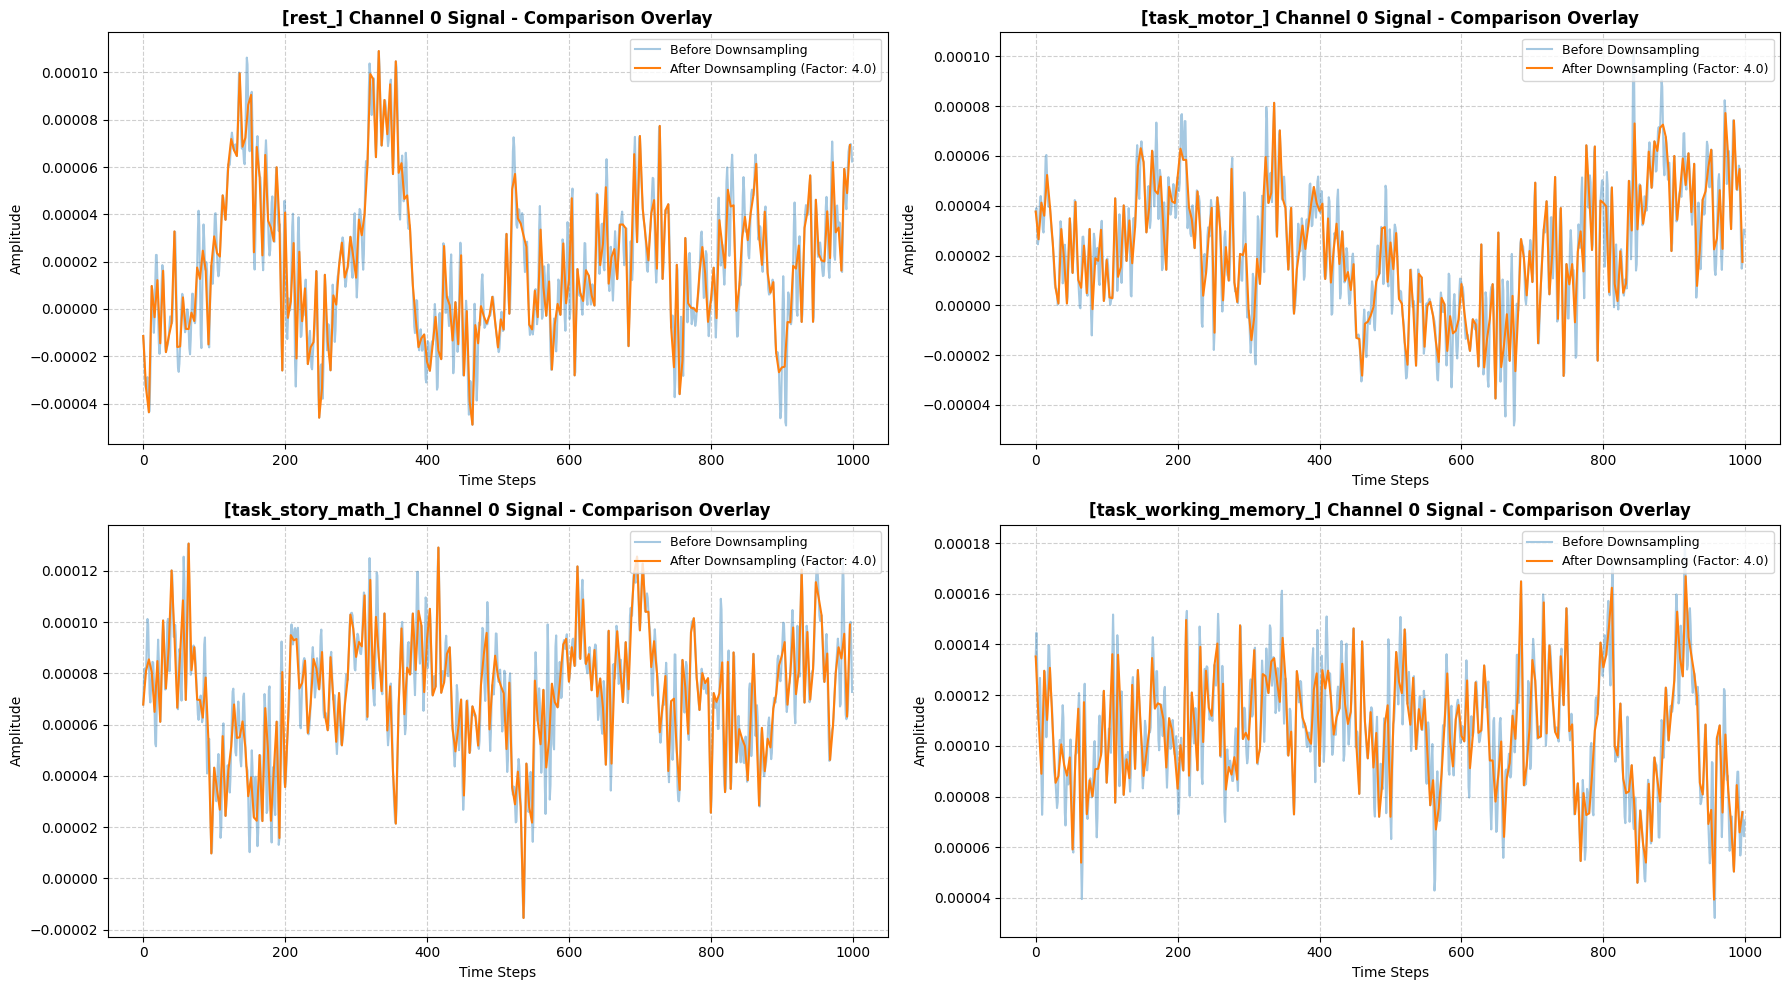

In [78]:
import numpy as np
import matplotlib.pyplot as plt

channel_to_visualize = 0
raw_time_window_length = 1000

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for idx, (prefix, data) in enumerate(task_data.items()):
    ax = axes[idx]
    
    preprocessed_matrix = data['preprocessed']
    downsampled_matrix = data['downsampled']
    downsample_factor = data['factor']
    
    time_window_raw = slice(0, raw_time_window_length)
    time_window_ds = slice(0, int(raw_time_window_length / downsample_factor))

    x_raw = np.arange(0, raw_time_window_length)
    x_ds = np.arange(0, int(raw_time_window_length / downsample_factor)) * downsample_factor

    ax.plot(x_raw, preprocessed_matrix[channel_to_visualize, time_window_raw], 
             label='Before Downsampling', color='#1f77b4', alpha=0.4, linewidth=1.5)

    ax.plot(x_ds, downsampled_matrix[channel_to_visualize, time_window_ds], 
             label=f'After Downsampling (Factor: {downsample_factor:.1f})', 
             color='#ff7f0e', alpha=1, linewidth=1.5, linestyle='-')

    ax.set_title(f'[{prefix}] Channel {channel_to_visualize} Signal - Comparison Overlay', fontsize=12, fontweight='bold')
    ax.set_xlabel('Time Steps', fontsize=10)
    ax.set_ylabel('Amplitude', fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/meg_signal_overlay_comparison_all_tasks.png', dpi=300)
plt.show()

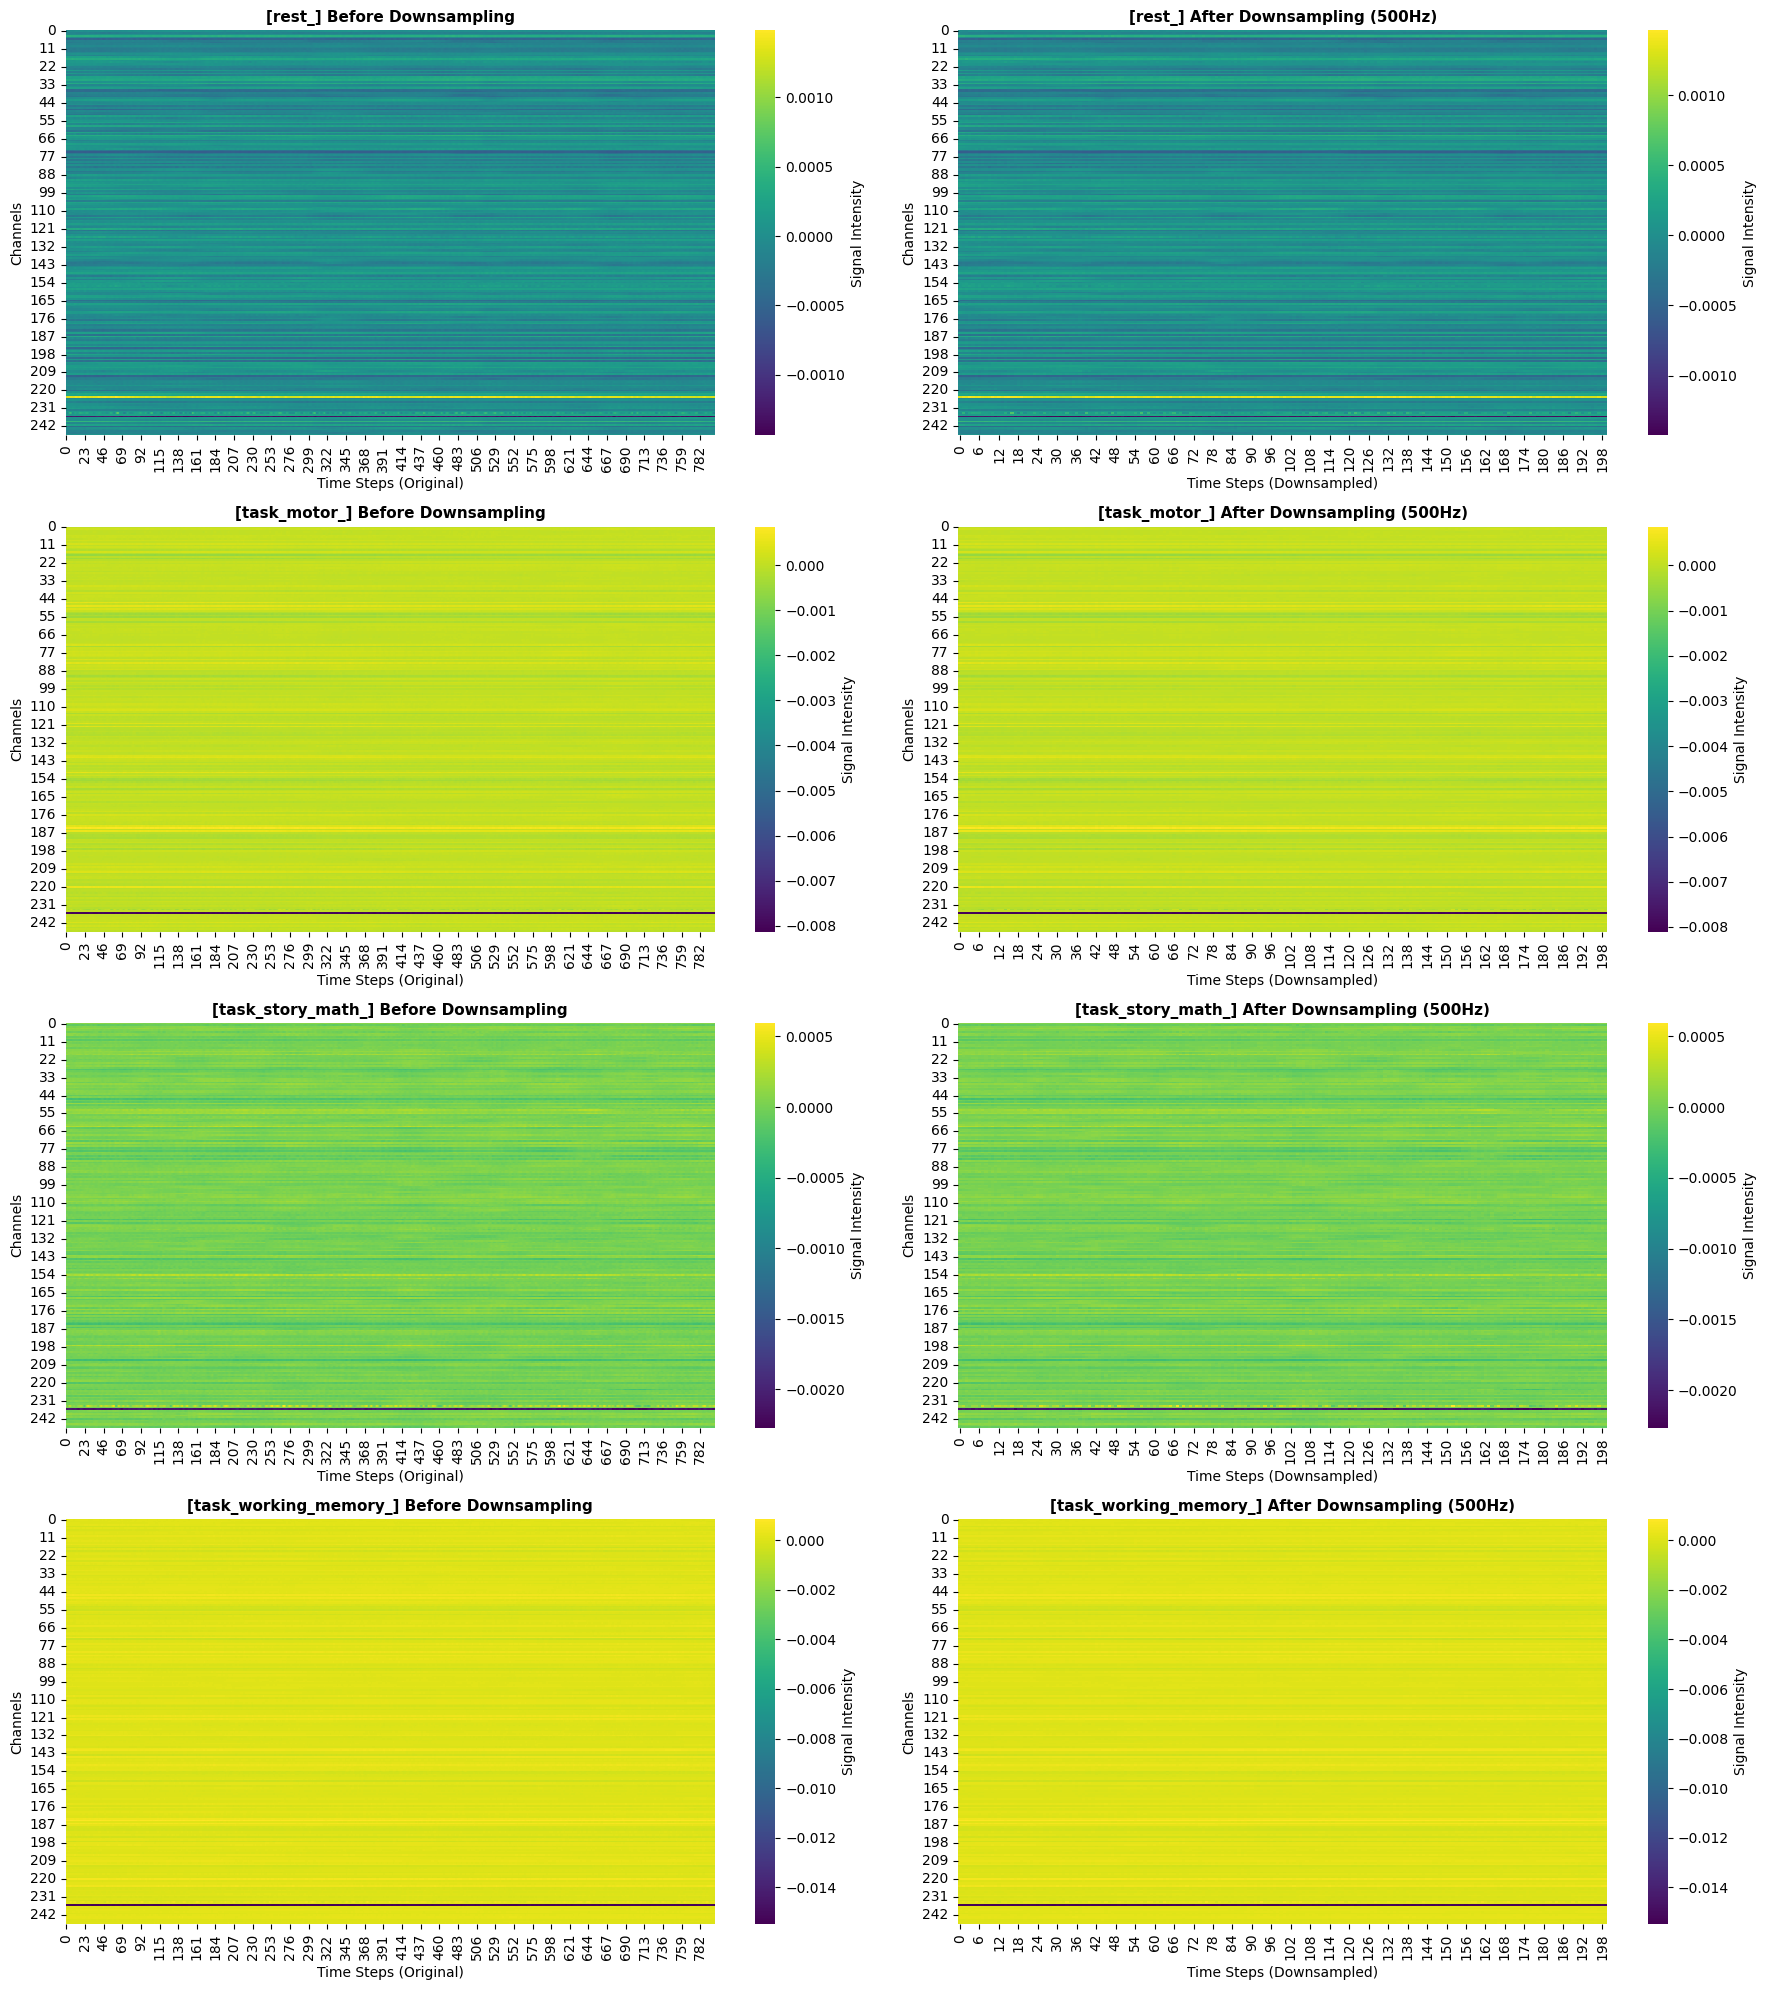

In [79]:
# --- Configuration ---
num_channels_to_plot = 248       # Number of channels to display on the y-axis
raw_heatmap_time_length = 800   # Number of time steps for the original heatmap

fig, axes = plt.subplots(4, 2, figsize=(18, 20))

for idx, (prefix, data) in enumerate(task_data.items()):
    ax1 = axes[idx, 0]
    ax2 = axes[idx, 1]
    
    preprocessed_matrix = data['preprocessed']
    downsampled_matrix = data['downsampled']
    downsample_factor = data['factor']
    
    # Define matching time windows for alignment
    heatmap_time_raw = preprocessed_matrix[:num_channels_to_plot, :raw_heatmap_time_length]
    heatmap_time_ds = downsampled_matrix[:num_channels_to_plot, :int(raw_heatmap_time_length / downsample_factor)]

    # 1. Heatmap Before Downsampling
    sns.heatmap(heatmap_time_raw, cmap='viridis', ax=ax1, 
                cbar_kws={'label': 'Signal Intensity'})
    ax1.set_title(f'[{prefix}] Before Downsampling', fontsize=11, fontweight='bold')
    ax1.set_xlabel('Time Steps (Original)', fontsize=10)
    ax1.set_ylabel('Channels', fontsize=10)

    # 2. Heatmap After Downsampling
    sns.heatmap(heatmap_time_ds, cmap='viridis', ax=ax2, 
                cbar_kws={'label': 'Signal Intensity'})
    ax2.set_title(f'[{prefix}] After Downsampling ({target_downsample_rate}Hz)', fontsize=11, fontweight='bold')
    ax2.set_xlabel('Time Steps (Downsampled)', fontsize=10)
    ax2.set_ylabel('Channels', fontsize=10)

plt.tight_layout()
plt.savefig('../reports/figures/meg_heatmap_comparison_all_tasks.png', dpi=300)
plt.show()

In [80]:
label_map = {
    "rest": 0,
    "task_motor": 1,
    "task_story_math": 2,
    "task_working_memory": 3
}

class MEGDataset(Dataset):
    def __init__(self, file_paths, persist_dir=None, downsample_rate=250):
        self.file_paths = file_paths
        self.persist_dir = persist_dir
        self.downsample_rate = downsample_rate
        if persist_dir:
            Path(persist_dir).mkdir(parents=True, exist_ok=True)
            
    def __len__(self):
        return len(self.file_paths)
        
    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        filename = file_path.name
        
        # map label from filename
        label_str = next((k for k in label_map.keys() if filename.startswith(k)), None)
        if label_str is None:
            raise ValueError(f"Unknown label in filename: {filename}")

        label = label_map[label_str]
        
        if self.persist_dir:
            save_path = Path(self.persist_dir) / f"{filename}.npy"
            if save_path.exists():
                matrix = np.load(save_path)
                return torch.tensor(matrix, dtype=torch.float32), torch.tensor(label, dtype=torch.long)
            
        with h5py.File(file_path, 'r') as f:
            dataset_name = "_".join(filename.split('_')[:-1])
            obj = f.get(dataset_name)
            if obj is None:
                raise ValueError(f"Dataset '{dataset_name}' not found in {file_path}")
            if not isinstance(obj, h5py.Dataset):
                raise TypeError(f"Expected h5py.Dataset, got {type(obj)}")
            matrix = obj[()]
            
        matrix = preprocess_matrix(matrix)
        matrix = downsample_matrix(matrix, downsample_rate=self.downsample_rate)
        
        if self.persist_dir:
            np.save(save_path, matrix)
            
        return torch.tensor(matrix, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

In [81]:
data_root = Path('..') / 'data' / 'raw' / 'Final Project data'
processed_dir = Path('..') / 'data' / 'processed'

intra_train_files = list((data_root / 'Intra' / 'train').rglob('*.h5'))
intra_test_files = list((data_root / 'Intra' / 'test').rglob('*.h5'))

intra_train_dataset = MEGDataset(intra_train_files, persist_dir=processed_dir)
intra_test_dataset = MEGDataset(intra_test_files, persist_dir=processed_dir)

batch_size = 16
intra_train_loader = DataLoader(intra_train_dataset, batch_size=batch_size, shuffle=True)
intra_test_loader = DataLoader(intra_test_dataset, batch_size=batch_size, shuffle=False)

print(f"intra: {len(intra_train_dataset)} train, {len(intra_test_dataset)} test")

intra: 32 train, 8 test


In [82]:
cross_train_files = list((data_root / 'Cross' / 'train').rglob('*.h5'))
cross_test_files = []
for i in [1, 2, 3]:
    cross_test_files.extend((data_root / 'Cross' / f'test{i}').rglob('*.h5'))

cross_train_dataset = MEGDataset(cross_train_files, persist_dir=processed_dir)
cross_test_dataset = MEGDataset(cross_test_files, persist_dir=processed_dir)

cross_train_loader = DataLoader(cross_train_dataset, batch_size=batch_size, shuffle=True)
cross_test_loader = DataLoader(cross_test_dataset, batch_size=batch_size, shuffle=False)

print(f"cross: {len(cross_train_dataset)} train, {len(cross_test_dataset)} test")

cross: 64 train, 48 test


In [83]:
class CNN_GRU_Classifier(nn.Module):
    def __init__(self, in_channels=248, num_classes=4, dropout=0.5, kernel_size=3, hidden_dim=64, negative_slope=0.01):
        super().__init__()
        
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, 248, kernel_size=kernel_size, padding=kernel_size // 2),
            nn.InstanceNorm1d(248),
            nn.LeakyReLU(negative_slope),
            nn.Dropout1d(0.2),
            nn.AvgPool1d(2),

            nn.Conv1d(248, 256, kernel_size=kernel_size, padding=kernel_size // 2),
            nn.InstanceNorm1d(256),
            nn.LeakyReLU(negative_slope),
            nn.AvgPool1d(2)
        )

        self.gru = nn.GRU(input_size=256, hidden_size=hidden_dim, num_layers=1,
                          batch_first=True, bidirectional=False)

        self.fc = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 128),
            nn.LeakyReLU(negative_slope),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.permute(0, 2, 1) # time last for gru
        _, h_n = self.gru(x)
        return self.fc(h_n.squeeze(0))
    
class CNN_1D_Classifier(nn.Module):
    def __init__(self, in_channels=248, num_classes=4, dropout=0.5, temp_kernel=31, negative_slope=0.01):
        super().__init__()
        
        # 1. Temporal Convolution: acts on each channel independently
        # For spatial-temporal decoupling, we use depthwise convolution via groups
        self.temporal_conv = nn.Conv1d(
            in_channels, in_channels, kernel_size=temp_kernel, 
            padding=temp_kernel // 2, groups=in_channels, bias=False
        )
        self.temp_norm = nn.InstanceNorm1d(in_channels)
        
        # 2. Spatial Convolution: mixes channels, Pointwise convolution (kernel=1)
        self.spatial_conv = nn.Conv1d(in_channels, 128, kernel_size=1, bias=False)
        self.spatial_norm = nn.InstanceNorm1d(128)
        
        self.pool1 = nn.AvgPool1d(2)
        
        # 3. Standard Convolution using larger abstracted features
        self.conv2 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=7, padding=3, bias=False),
            nn.InstanceNorm1d(256),
            nn.LeakyReLU(negative_slope),
            nn.AdaptiveAvgPool1d(1)
        )
        
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(256, 128),
            nn.LeakyReLU(negative_slope),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )
        self.act = nn.LeakyReLU(negative_slope)

    def forward(self, x):
        x = self.temporal_conv(x)
        x = self.temp_norm(x)
        x = self.act(x)
        
        x = self.spatial_conv(x)
        x = self.spatial_norm(x)
        x = self.act(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        return self.fc(x)

def build_model(input_channels=248):
    return CNN_1D_Classifier(in_channels=input_channels, num_classes=4)

model = build_model()
print(model)

CNN_1D_Classifier(
  (temporal_conv): Conv1d(248, 248, kernel_size=(31,), stride=(1,), padding=(15,), groups=248, bias=False)
  (temp_norm): InstanceNorm1d(248, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
  (spatial_conv): Conv1d(248, 128, kernel_size=(1,), stride=(1,), bias=False)
  (spatial_norm): InstanceNorm1d(128, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
  (pool1): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
  (conv2): Sequential(
    (0): Conv1d(128, 256, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
    (1): InstanceNorm1d(256, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
    (2): LeakyReLU(negative_slope=0.01)
    (3): AdaptiveAvgPool1d(output_size=1)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Dropout(p=0.5, inplace=False)
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): LeakyReLU(negative_slope=0.01)
    (4): Dropout(p=0.5, inplace=Fal

In [84]:
import copy
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

def train_model(model, train_loader, test_loader, num_epochs=50, learning_rate=1e-3, patience=20):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    # Label Smoothing to address mode collapse
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    
    # AdamW works better with CosineAnnealing
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4) 
    
    # Cosine Annealing scheduler with warm restarts
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2, eta_min=1e-5)
    
    results = {'train_acc': [], 'test_acc': [], 'train_loss': [], 'test_loss': []}
    
    best_test_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    patience_counter = 0
    
    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
        epoch_loss = running_loss / total
        epoch_acc = correct / total
        
        model.eval()
        test_loss_sum, test_correct, test_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                test_loss_sum += loss.item() * inputs.size(0)
                
                _, predicted = torch.max(outputs, 1)
                test_total += labels.size(0)
                test_correct += (predicted == labels).sum().item()
                
        test_loss = test_loss_sum / test_total if test_total > 0 else 0
        test_acc = test_correct / test_total if test_total > 0 else 0
        
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch+1:02d}/{num_epochs} - Train Loss: {epoch_loss:.4f} - Train Acc: {epoch_acc:.4f} - Test Loss: {test_loss:.4f} - Test Acc: {test_acc:.4f} - LR: {current_lr:.2e}")
        
        scheduler.step()
        
        results['train_loss'].append(epoch_loss)
        results['train_acc'].append(epoch_acc)
        results['test_loss'].append(test_loss)
        results['test_acc'].append(test_acc)
        
        # Early Stopping based on validation loss
        if test_loss < best_test_loss:
            best_test_loss = test_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break
                
    # Load the best model weights
    model.load_state_dict(best_model_wts)
    return results

print("running intra-subject training")
intra_model = build_model()
intra_subject_results = train_model(intra_model, intra_train_loader, intra_test_loader, num_epochs=50)

running intra-subject training
Epoch 01/50 - Train Loss: 1.4391 - Train Acc: 0.1875 - Test Loss: 1.3622 - Test Acc: 0.2500 - LR: 1.00e-03
Epoch 02/50 - Train Loss: 1.3869 - Train Acc: 0.2188 - Test Loss: 1.3449 - Test Acc: 0.2500 - LR: 9.76e-04
Epoch 03/50 - Train Loss: 1.3509 - Train Acc: 0.3438 - Test Loss: 1.3272 - Test Acc: 0.3750 - LR: 9.05e-04
Epoch 04/50 - Train Loss: 1.3075 - Train Acc: 0.5938 - Test Loss: 1.3139 - Test Acc: 0.6250 - LR: 7.96e-04
Epoch 05/50 - Train Loss: 1.3147 - Train Acc: 0.4375 - Test Loss: 1.3002 - Test Acc: 0.7500 - LR: 6.58e-04
Epoch 06/50 - Train Loss: 1.2643 - Train Acc: 0.6250 - Test Loss: 1.2873 - Test Acc: 0.7500 - LR: 5.05e-04
Epoch 07/50 - Train Loss: 1.2972 - Train Acc: 0.5000 - Test Loss: 1.2780 - Test Acc: 0.7500 - LR: 3.52e-04
Epoch 08/50 - Train Loss: 1.2659 - Train Acc: 0.5000 - Test Loss: 1.2714 - Test Acc: 0.7500 - LR: 2.14e-04
Epoch 09/50 - Train Loss: 1.2732 - Train Acc: 0.5000 - Test Loss: 1.2678 - Test Acc: 0.7500 - LR: 1.05e-04
Epoch 

In [85]:
print("running cross-subject training")
cross_model = build_model()
cross_subject_results = train_model(cross_model, cross_train_loader, cross_test_loader, num_epochs=50)

running cross-subject training
Epoch 01/50 - Train Loss: 1.4087 - Train Acc: 0.2344 - Test Loss: 1.3624 - Test Acc: 0.4792 - LR: 1.00e-03
Epoch 02/50 - Train Loss: 1.3531 - Train Acc: 0.4219 - Test Loss: 1.3439 - Test Acc: 0.5417 - LR: 9.76e-04
Epoch 03/50 - Train Loss: 1.3196 - Train Acc: 0.4375 - Test Loss: 1.3163 - Test Acc: 0.5417 - LR: 9.05e-04
Epoch 04/50 - Train Loss: 1.2808 - Train Acc: 0.5000 - Test Loss: 1.2830 - Test Acc: 0.5833 - LR: 7.96e-04
Epoch 05/50 - Train Loss: 1.2317 - Train Acc: 0.6094 - Test Loss: 1.2531 - Test Acc: 0.5625 - LR: 6.58e-04
Epoch 06/50 - Train Loss: 1.1958 - Train Acc: 0.6562 - Test Loss: 1.2310 - Test Acc: 0.5625 - LR: 5.05e-04
Epoch 07/50 - Train Loss: 1.1866 - Train Acc: 0.6562 - Test Loss: 1.2136 - Test Acc: 0.5625 - LR: 3.52e-04
Epoch 08/50 - Train Loss: 1.1430 - Train Acc: 0.6875 - Test Loss: 1.2027 - Test Acc: 0.5833 - LR: 2.14e-04
Epoch 09/50 - Train Loss: 1.1453 - Train Acc: 0.6875 - Test Loss: 1.1961 - Test Acc: 0.6042 - LR: 1.05e-04
Epoch 

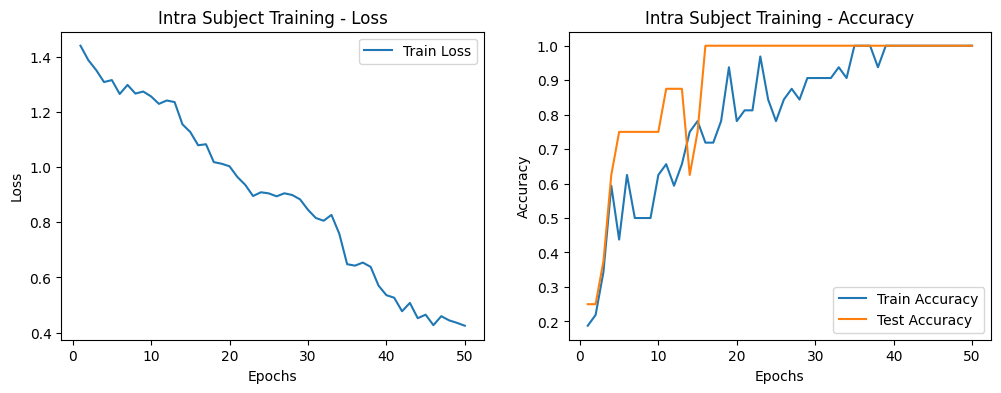

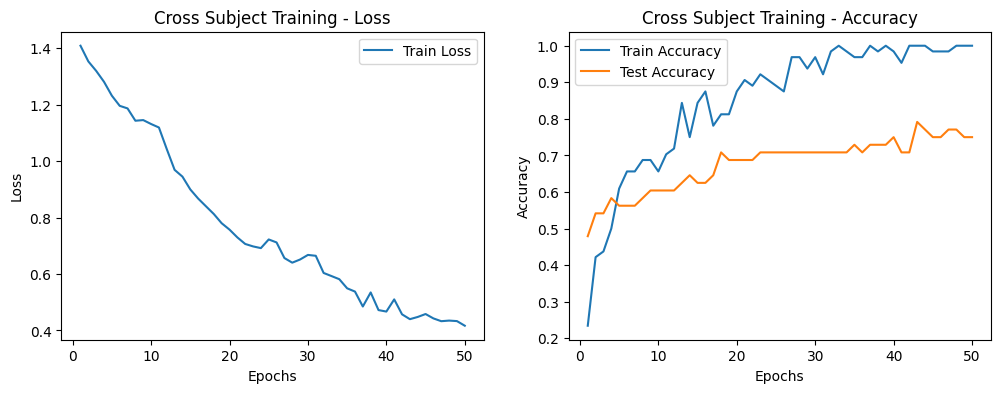

Intra-Subject Test Acc: 1.0000
Cross-Subject Test Acc: 0.7500
Gap: 0.2500


In [86]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_learning_curves(results_dict, title):
    epochs = range(1, len(results_dict['train_loss']) + 1)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(epochs, results_dict['train_loss'], label='Train Loss')
    ax1.set_title(f'{title} - Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()
    
    ax2.plot(epochs, results_dict['train_acc'], label='Train Accuracy')
    ax2.plot(epochs, results_dict['test_acc'], label='Test Accuracy')
    ax2.set_title(f'{title} - Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    
    Path('../reports/figures').mkdir(parents=True, exist_ok=True)
    plt.savefig(f"../reports/figures/{title.replace(' ', '_')}.png")
    plt.show()

plot_learning_curves(intra_subject_results, 'Intra Subject Training')
plot_learning_curves(cross_subject_results, 'Cross Subject Training')

print(f"Intra-Subject Test Acc: {intra_subject_results['test_acc'][-1]:.4f}")
print(f"Cross-Subject Test Acc: {cross_subject_results['test_acc'][-1]:.4f}")
print(f"Gap: {intra_subject_results['test_acc'][-1] - cross_subject_results['test_acc'][-1]:.4f}")

In [87]:
print("training cnn-gru approach...")
alt_model = CNN_GRU_Classifier(in_channels=248, num_classes=4)
alt_results = train_model(alt_model, cross_train_loader, cross_test_loader, num_epochs=50, learning_rate=5e-4)

plot_learning_curves(alt_results, 'CNN-GRU Cross Subject')
print(f"CNN-GRU Test Acc: {alt_results['test_acc'][-1]:.4f}")

training cnn-gru approach...


RuntimeError: Given groups=1, weight of size [248, 248, 3, 3], expected input[1, 16, 248, 4453] to have 248 channels, but got 16 channels instead

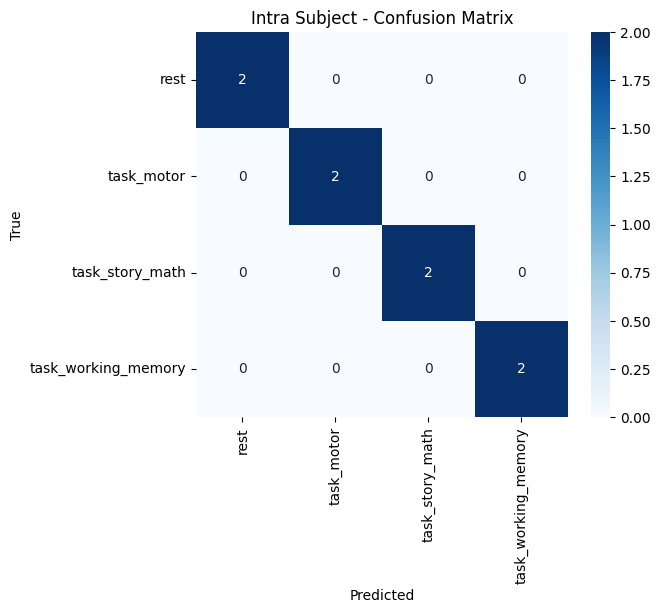

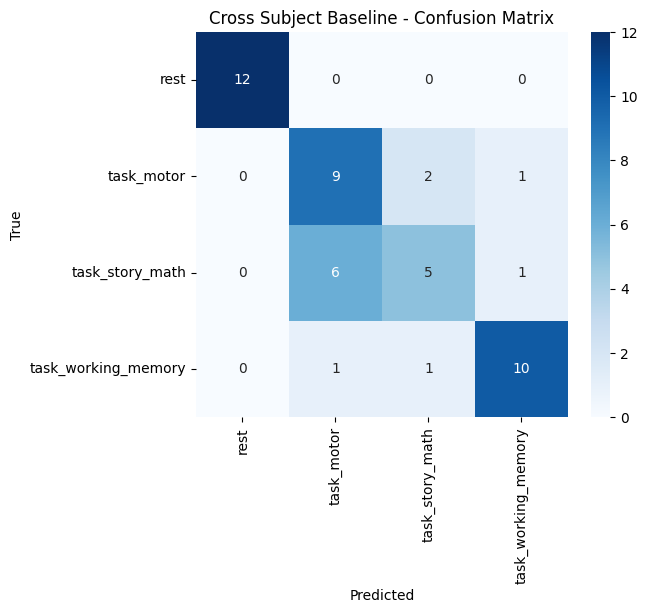

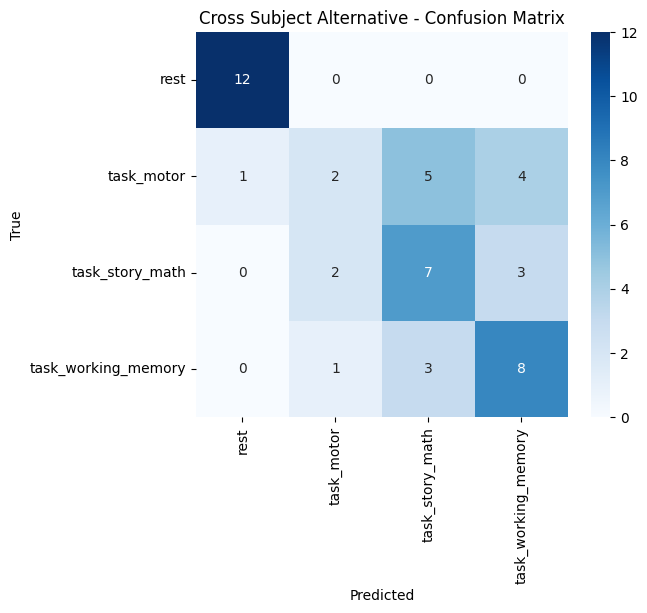

In [ ]:
def plot_confusion_matrix(model, test_loader, title):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()
    
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=list(label_map.keys()), 
                yticklabels=list(label_map.keys()))
    plt.title(f'{title} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    
    plt.savefig(f"../reports/figures/cm_{title.replace(' ', '_')}.png")
    plt.show()

plot_confusion_matrix(intra_model, intra_test_loader, 'Intra Subject Baseline CNN_1D_Classifier')
plot_confusion_matrix(cross_model, cross_test_loader, 'Cross Subject Baseline CNN_1D_Classifier')
plot_confusion_matrix(alt_model, cross_test_loader, 'Cross Subject CNN_GRU_Classifier')

testing different learning rates

--- LR: 0.001 ---
Epoch 01/30 - Train Loss: 1.3763 - Train Acc: 0.3125 - Test Loss: 1.3497 - Test Acc: 0.5000 - LR: 1.00e-03
Epoch 02/30 - Train Loss: 1.3523 - Train Acc: 0.3438 - Test Loss: 1.3213 - Test Acc: 0.5000 - LR: 9.76e-04
Epoch 03/30 - Train Loss: 1.3389 - Train Acc: 0.4062 - Test Loss: 1.2978 - Test Acc: 0.5000 - LR: 9.05e-04
Epoch 04/30 - Train Loss: 1.2940 - Train Acc: 0.4062 - Test Loss: 1.2776 - Test Acc: 0.5000 - LR: 7.96e-04
Epoch 05/30 - Train Loss: 1.2919 - Train Acc: 0.5938 - Test Loss: 1.2604 - Test Acc: 0.5000 - LR: 6.58e-04
Epoch 06/30 - Train Loss: 1.2780 - Train Acc: 0.6250 - Test Loss: 1.2432 - Test Acc: 0.5000 - LR: 5.05e-04
Epoch 07/30 - Train Loss: 1.2579 - Train Acc: 0.4688 - Test Loss: 1.2301 - Test Acc: 0.5000 - LR: 3.52e-04
Epoch 08/30 - Train Loss: 1.2375 - Train Acc: 0.5625 - Test Loss: 1.2218 - Test Acc: 0.5000 - LR: 2.14e-04
Epoch 09/30 - Train Loss: 1.2209 - Train Acc: 0.7188 - Test Loss: 1.2174 - Test Acc: 0.5000 

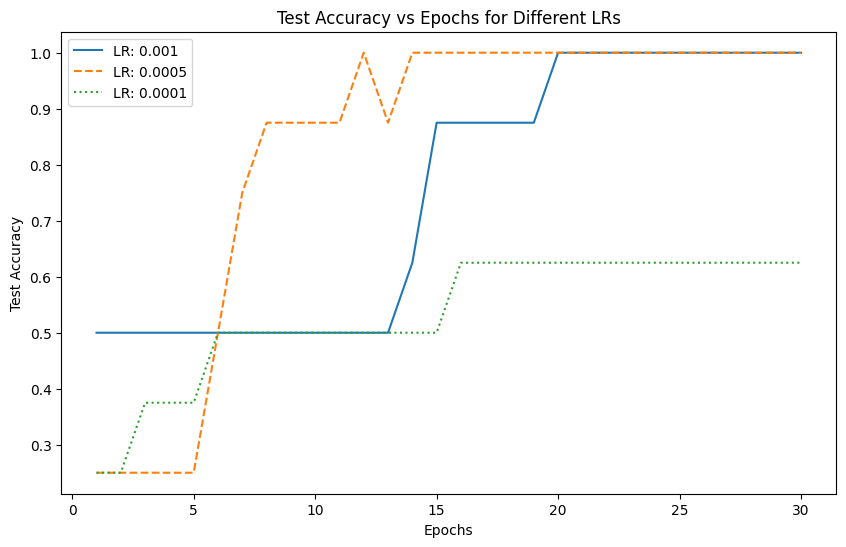

In [ ]:
learning_rates = [1e-3, 5e-4, 1e-4]
hyper_results = {}

print("testing different learning rates")
for lr in learning_rates:
    print(f"\n--- LR: {lr} ---")
    hyper_model = build_model()
    res = train_model(hyper_model, intra_train_loader, intra_test_loader, num_epochs=30, learning_rate=lr)
    hyper_results[str(lr)] = res

plt.figure(figsize=(10, 6))
for lr, res in hyper_results.items():
    # Differentiate curves by linestyle
    if lr == str(learning_rates[0]):
        linestyle = '-'
    elif lr == str(learning_rates[1]):
        linestyle = '--'
    elif lr == str(learning_rates[2]):
        linestyle = ':'
    plt.plot(range(1, len(res['test_acc']) + 1), res['test_acc'], label=f'LR: {lr}', linestyle=linestyle)

plt.title('Test Accuracy vs Epochs for Different LRs')
plt.xlabel('Epochs')
plt.ylabel('Test Accuracy')
plt.legend()
plt.savefig("../reports/figures/lr_comparison.png")
plt.show()

# Metrics to report

Confusion Matrix, F1-Score, ROC-AUC, MAE, RMSE, 